
# Finlora Finance Flow – Transaction Fraud Risk Scoring Project

## Project Overview

Finlora Finance Flow is a fintech platform processing transactions across individual and business accounts, multiple payment channels, and different customer segments. As transaction volumes increase, traditional fixed-threshold fraud rules can generate large numbers of false alerts while potentially missing more subtle fraudulent activity.

This project explores the use of machine learning to improve transaction monitoring by assigning each transaction a probability of fraud rather than relying solely on binary rule-based alerts.

### Project Aim

The aim is to develop an explainable fraud risk-scoring model that uses transaction and account-level behavioural information to identify potentially fraudulent transactions and prioritise them for analyst review.

### Key Objectives

 Clean and prepare Finlora's transaction and account data.
 Explore behavioural differences between fraudulent and legitimate transactions.
 Engineer meaningful risk indicators such as transaction amount relative to account baseline, transaction       
 velocity, new-device activity and cross-border activity.
 Develop Logistic Regression as an interpretable baseline model.
 Develop Random Forest as the primary prototype model.
 Compare model performance using Precision, Recall, F1-score and ROC-AUC.
 Analyse different operating thresholds at 70%, 80% and 90% recall.
 Identify the key behavioural features associated with fraud risk.
 Deploy the prototype through a Streamlit dashboard providing a prioritised and explainable transaction-review queue.

### Expected Business Value

The proposed solution is designed to help Finlora:

 Prioritise high-risk transactions for analyst investigation.
 Reduce unnecessary manual review of lower-risk alerts.
 Identify behavioural patterns associated with fraudulent activity.
 Provide analysts with explainable risk indicators rather than black-box predictions.
 Support a more scalable approach to transaction monitoring as transaction volumes grow.

### Project Scope

This is a prototype based on historical transaction and account data. It does not include live payment-system integration, automated transaction blocking, production deployment, automated model retraining or regulatory approval.

The overall workflow is:

**Data Preparation → Exploratory Analysis → Feature Engineering → Model Development → Model Evaluation → Explainability → Streamlit Deployment**

The project evaluates whether machine-learning-based risk scoring can provide Finlora with a more informative and prioritised approach to transaction fraud monitoring.

## Data Profiling — Data Quality, Structure, Distributions & Class Imbalance

In [1]:
# Import libraries
import pandas as pd
from pathlib import Path
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
# Folder containing the datasets
data_folder = Path(r"C:\Users\telvi\Downloads\AMDARI\finlora_finance_flow\data")

In [3]:
# Load the datasets 
transactions = pd.read_csv(data_folder / "finlora_transactions.csv")
accounts = pd.read_csv(data_folder / "finlora_accounts.csv")

In [4]:
 # Dataset Overview
print("TRANSACTIONS DATASET")
print(f"Rows: {transactions.shape[0]:,}")
print(f"Columns: {transactions.shape[1]:,}")

TRANSACTIONS DATASET
Rows: 126,000
Columns: 24


In [5]:
print("ACCOUNTS DATASET")
print(f"Rows: {accounts.shape [0]:,}")
print(f"Columns: {accounts.shape [1]:,}")

ACCOUNTS DATASET
Rows: 7,200
Columns: 8


In [6]:
# Structure and data types
# Dataset structure
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   transaction_id              126000 non-null  object 
 1   account_id                  126000 non-null  object 
 2   account_type                126000 non-null  object 
 3   kyc_tier                    126000 non-null  object 
 4   timestamp                   126000 non-null  object 
 5   day_of_week                 126000 non-null  object 
 6   hour_of_day                 126000 non-null  int64  
 7   description                 126000 non-null  object 
 8   merchant_name               97390 non-null   object 
 9   merchant_category           126000 non-null  object 
 10  channel                     126000 non-null  object 
 11  amount                      126000 non-null  float64
 12  currency                    126000 non-null  object 
 13  amount_to_avg_

In [7]:
# Convert the timestamp column from text (object) to a proper datetime format.
transactions['timestamp'] = pd.to_datetime(
    transactions['timestamp'],
    errors='coerce'
)

In [8]:
# Check the data type of the timestamp column to confirm that it was converted successfully.
transactions['timestamp'].dtype

dtype('<M8[ns]')

In [9]:
# Dataset structure
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   account_id                   7200 non-null   object 
 1   account_holder_name          7200 non-null   object 
 2   account_type                 7200 non-null   object 
 3   home_country                 7200 non-null   object 
 4   currency                     7200 non-null   object 
 5   kyc_tier                     7200 non-null   object 
 6   account_created_date         7200 non-null   object 
 7   personal_spend_baseline_usd  7200 non-null   float64
dtypes: float64(1), object(7)
memory usage: 450.1+ KB


In [10]:
# Preview the data
transactions.head()

,transaction_id,account_id,account_type,kyc_tier,timestamp,day_of_week,hour_of_day,description,merchant_name,merchant_category,...,avg_transaction_amount_30d,transaction_velocity_1h,transaction_country,home_country,is_cross_border,device_id,is_new_device,account_age_days,status,is_fraud
0,FLR250216186265,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-02-16 14:55:35,Sunday,14,CNP PURCHASE - BOLT,Bolt,Travel,...,9143.33,0,NG,NG,0,NaN,NaN,903,Completed,0
1,FLR250423143305,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-23 13:35:40,Wednesday,13,WEB PURCHASE - SLACK,Slack,Subscription/SaaS,...,9143.33,0,NG,NG,0,NaN,NaN,969,Declined,0
2,FLR250424154897,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-24 12:30:34,Thursday,12,MOBILE PURCHASE - JUSTRITE SUPERSTORE,Justrite Superstore,Groceries,...,9143.33,0,NG,NG,0,DEV-9055235108,0.0,970,Completed,0
3,FLR250428101772,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-28 14:41:59,Monday,14,CNP PURCHASE - ADOBE CREATIVE CLOUD,Adobe Creative Cloud,Subscription/SaaS,...,14891.16,0,NG,NG,0,NaN,NaN,974,Completed,0
4,FLR250628102827,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-06-28 16:15:47,Saturday,16,MOBILE PURCHASE - APPLE STORE,Apple Store,Electronics,...,49609.59,0,NG,NG,0,DEV-9055235108,0.0,1035,Declined,0


In [11]:
# Preview the data
accounts.head()

,account_id,account_holder_name,account_type,home_country,currency,kyc_tier,account_created_date,personal_spend_baseline_usd
0,FLR-ACC-100000,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23
1,FLR-ACC-100001,Bluewave Foods Ltd,Business,NG,NGN,Tier1_Basic,2026-04-27,810.68
2,FLR-ACC-100002,Global Trading LLC,Business,US,USD,Tier2_Verified,2026-03-29,433.67
3,FLR-ACC-100003,Femi Adeyemi,Individual,NG,NGN,Tier3_Enhanced,2025-09-15,19.18
4,FLR-ACC-100004,Ngozi Brown,Individual,NG,NGN,Tier3_Enhanced,2024-06-18,28.68


In [12]:
# display statistical summary of numerical and categorical column
transactions.describe(include='all')

,transaction_id,account_id,account_type,kyc_tier,timestamp,day_of_week,hour_of_day,description,merchant_name,merchant_category,...,avg_transaction_amount_30d,transaction_velocity_1h,transaction_country,home_country,is_cross_border,device_id,is_new_device,account_age_days,status,is_fraud
count,126000,126000,126000,126000,126000,126000,126000.000000,126000,97390,126000,...,1.260000e+05,126000.000000,126000,126000,126000.000000,111666,111666.000000,126000.000000,126000,126000.000000
unique,126000,7144,2,3,NaN,7,NaN,8644,63,15,...,NaN,NaN,5,5,NaN,14931,NaN,NaN,3,NaN
top,FLR250216186265,FLR-ACC-101374,Individual,Tier2_Verified,NaN,Sunday,NaN,ATM WITHDRAWAL - CHASE ATM,International Wire,Payroll Transfer,...,NaN,NaN,NG,NG,NaN,DEV-6618186337,NaN,NaN,Completed,NaN
freq,1,1497,82112,64094,NaN,18402,NaN,1055,7584,17117,...,NaN,NaN,63208,64185,NaN,1299,NaN,NaN,116703,NaN
mean,NaN,NaN,NaN,NaN,2025-11-17 18:17:27.700087296,NaN,13.542111,NaN,NaN,NaN,...,7.675995e+05,0.011429,NaN,NaN,0.020198,NaN,0.034881,354.721992,NaN,0.026603
min,NaN,NaN,NaN,NaN,2025-02-01 00:05:31,NaN,0.000000,NaN,NaN,NaN,...,-1.669153e+06,0.000000,NaN,NaN,0.000000,NaN,0.000000,0.000000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,2025-07-11 09:22:28,NaN,9.000000,NaN,NaN,NaN,...,9.242750e+01,0.000000,NaN,NaN,0.000000,NaN,0.000000,35.000000,NaN,0.000000
50%,NaN,NaN,NaN,NaN,2025-11-27 22:33:02.500000,NaN,14.000000,NaN,NaN,NaN,...,5.942240e+03,0.000000,NaN,NaN,0.000000,NaN,0.000000,289.000000,NaN,0.000000
75%,NaN,NaN,NaN,NaN,2026-03-24 12:34:02.750000128,NaN,18.000000,NaN,NaN,NaN,...,1.575701e+05,0.000000,NaN,NaN,0.000000,NaN,0.000000,577.000000,NaN,0.000000
max,NaN,NaN,NaN,NaN,2026-08-30 23:33:21,NaN,23.000000,NaN,NaN,NaN,...,1.733621e+08,3.000000,NaN,NaN,1.000000,NaN,1.000000,1682.000000,NaN,1.000000


In [13]:
accounts.describe(include='all')

,account_id,account_holder_name,account_type,home_country,currency,kyc_tier,account_created_date,personal_spend_baseline_usd
count,7200,7200,7200,7200,7200,7200,7200,7200.000000
unique,7200,1000,2,5,4,3,1443,NaN
top,FLR-ACC-100000,Kemi Bello,Individual,NG,NGN,Tier2_Verified,2025-02-15,NaN
freq,1,17,4735,3664,3664,3536,16,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,268.854419
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,495.820753
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.770000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.787500
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87.665000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,286.807500


In [14]:
# Measure missing data
transactions.isna().sum()

transaction_id                    0
account_id                        0
account_type                      0
kyc_tier                          0
timestamp                         0
day_of_week                       0
hour_of_day                       0
description                       0
merchant_name                 28610
merchant_category                 0
channel                           0
amount                            0
currency                          0
amount_to_avg_ratio               0
avg_transaction_amount_30d        0
transaction_velocity_1h           0
transaction_country               0
home_country                      0
is_cross_border                   0
device_id                     14334
is_new_device                 14334
account_age_days                  0
status                            0
is_fraud                          0
dtype: int64

In [15]:
# Measure missing data
accounts.isna().sum()

account_id                     0
account_holder_name            0
account_type                   0
home_country                   0
currency                       0
kyc_tier                       0
account_created_date           0
personal_spend_baseline_usd    0
dtype: int64

In [16]:
# Displaying missing value in percentage
transaction_missing_pct = (
    transactions.isna().mean() * 100
).sort_values(ascending=False)

display(
    transaction_missing_pct.to_frame("Missing %").round(2)
)

,Missing %
merchant_name,22.71
is_new_device,11.38
device_id,11.38
transaction_id,0.00
amount_to_avg_ratio,0.00
status,0.00
account_age_days,0.00
is_cross_border,0.00
home_country,0.00
transaction_country,0.00


In [17]:
account_missing_pct = (
    accounts.isna().mean() * 100
).sort_values(ascending=False)

display(
    account_missing_pct.to_frame("Missing %").round(2)
)

,Missing %
account_id,0.0
account_holder_name,0.0
account_type,0.0
home_country,0.0
currency,0.0
kyc_tier,0.0
account_created_date,0.0
personal_spend_baseline_usd,0.0


In [36]:
# VISUALISE NUMERICAL DISTRIBUTIONS
# Identify all numerical columns in the transaction dataset
numeric_cols = transactions.select_dtypes(
    include=np.number
).columns
print(numeric_cols)

Index(['hour_of_day', 'amount', 'amount_to_avg_ratio',
       'avg_transaction_amount_30d', 'transaction_velocity_1h',
       'is_cross_border', 'is_new_device', 'account_age_days', 'is_fraud'],
      dtype='object')


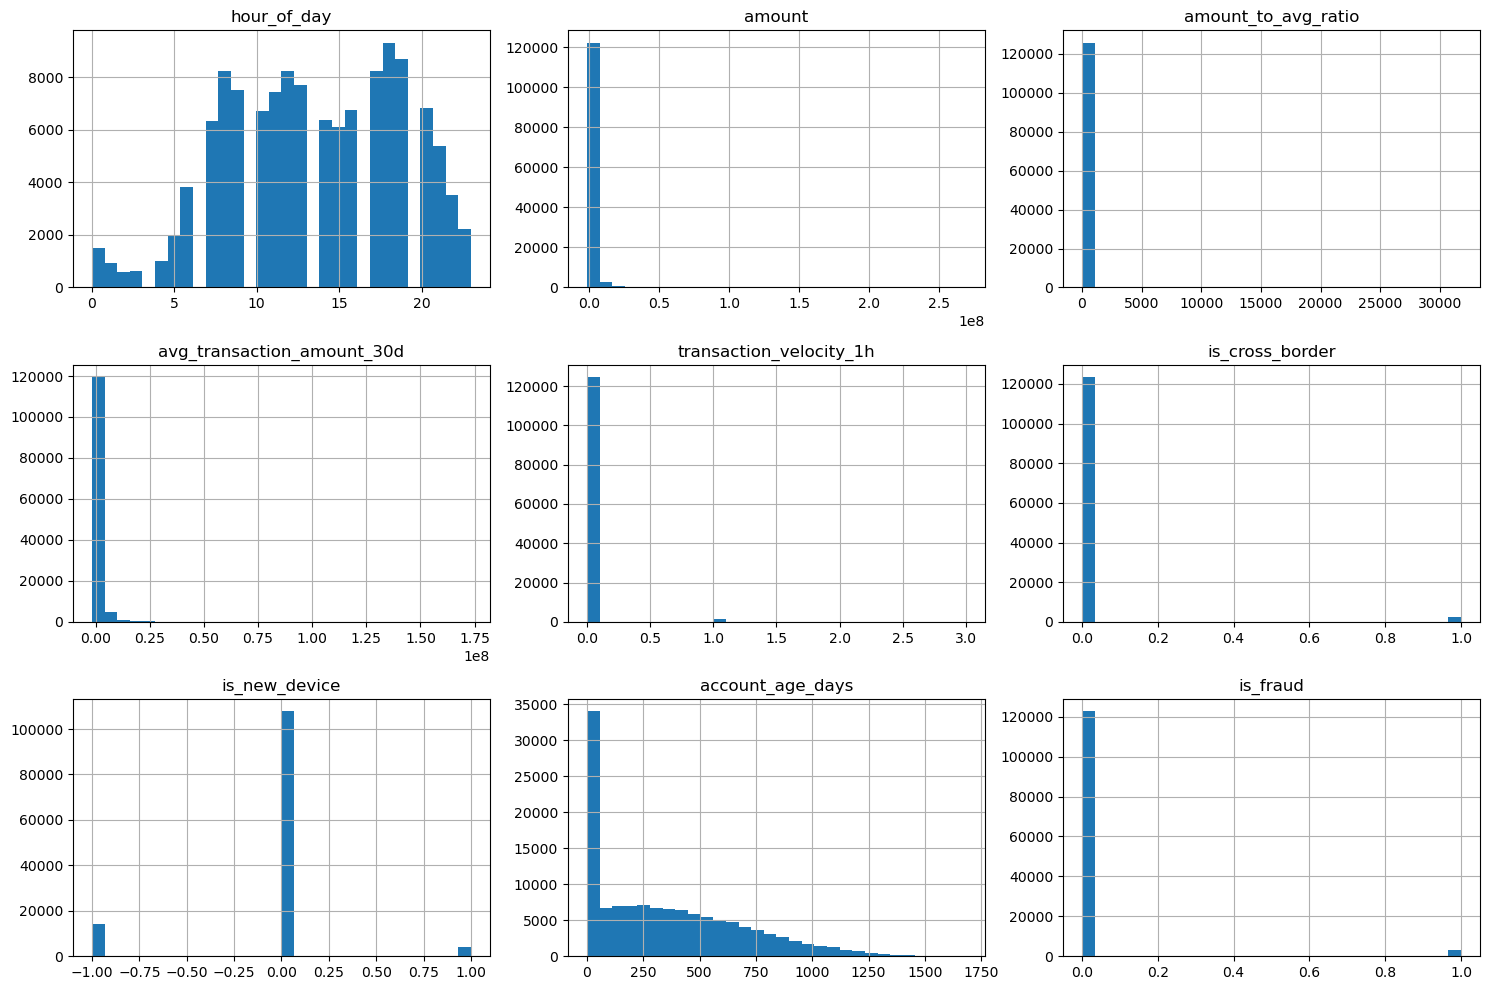

In [37]:
# Create histograms to examine the distribution of numerical variables
# This can help identify skewness, unusual values and potential outliers
transactions[numeric_cols].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

In [40]:
# EXAMINE CATEGORICAL DISTRIBUTIONS
# Identify categorical/text columns in the transaction dataset
categorical_cols = transactions.select_dtypes(
    include=["object", "category"]
).columns
print(categorical_cols)


Index(['transaction_id', 'account_id', 'account_type', 'kyc_tier',
       'day_of_week', 'description', 'merchant_name', 'merchant_category',
       'channel', 'currency', 'transaction_country', 'home_country',
       'device_id', 'status'],
      dtype='object')


In [41]:
# Display the frequency of each category
# dropna=False allows missing values to be included in the inspection
for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(
        transactions[col].value_counts(
            dropna=False
        )
    )


--- transaction_id ---


transaction_id
FLR250216186265    1
FLR250425177131    1
FLR250406144284    1
FLR250403142364    1
FLR250401147554    1
                  ..
FLR250803167134    1
FLR250722168990    1
FLR250708225486    1
FLR250706183858    1
FLR260726158421    1
Name: count, Length: 126000, dtype: int64


--- account_id ---


account_id
FLR-ACC-101374    1497
FLR-ACC-100134    1064
FLR-ACC-101024     760
FLR-ACC-100827     751
FLR-ACC-105168     686
                  ... 
FLR-ACC-100977       1
FLR-ACC-101785       1
FLR-ACC-101802       1
FLR-ACC-103879       1
FLR-ACC-104549       1
Name: count, Length: 7144, dtype: int64


--- account_type ---


...

home_country
NG    64185
US    24900
GB    18966
FR     9649
DE     8300
Name: count, dtype: int64


--- device_id ---


device_id
Unknown           14334
DEV-6618186337     1299
DEV-2644327725      905
DEV-9358605255      639
DEV-2240544904      590
                  ...  
DEV-8929684070        1
DEV-3074623778        1
DEV-9315314650        1
DEV-7689744883        1
DEV-1194729205        1
Name: count, Length: 14932, dtype: int64


--- status ---


status
Completed    116703
Declined       5629
Reversed       3668
Name: count, dtype: int64

In [42]:
# HECK FRAUD CLASS DISTRIBUTION
# Count the number of transactions in each fraud class
# This is important because fraud datasets are often imbalanced
fraud_counts = transactions["is_fraud"].value_counts(
    dropna=False
)

print("Fraud Class Counts:")
display(fraud_counts)

Fraud Class Counts:


is_fraud
0    122648
1      3352
Name: count, dtype: int64

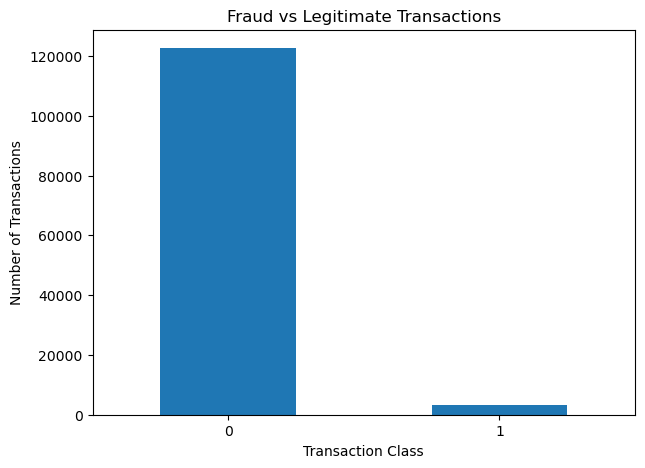

In [43]:
# VISUALISE FRAUD CLASS IMBALANCE
# Create a bar chart showing legitimate versus fraudulent transactions
fraud_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

In [44]:
# # Inspect the actual unique values in categorical variables.
# This can reveal spelling mistakes, inconsistent capitalisation
# and unexpected categories before the cleaning stage.

for col in categorical_cols:
    print(f"\n===== {col} =====")
    
    display(
        transactions[col]
        .dropna()
        .unique()
    )


===== transaction_id =====


array(['FLR250216186265', 'FLR250423143305', 'FLR250424154897', ...,
       'FLR260628219315', 'FLR260715110692', 'FLR260726158421'],
      shape=(126000,), dtype=object)


===== account_id =====


array(['FLR-ACC-100000', 'FLR-ACC-100001', 'FLR-ACC-100002', ...,
       'FLR-ACC-107197', 'FLR-ACC-107198', 'FLR-ACC-107199'],
      shape=(7144,), dtype=object)


===== account_type =====


...

array(['NG', 'US', 'FR', 'GB', 'DE'], dtype=object)


===== device_id =====


array(['Unknown', 'DEV-9055235108', 'DEV-6361365398', ...,
       'DEV-2290899062', 'DEV-9351005635', 'DEV-1194729205'],
      shape=(14932,), dtype=object)


===== status =====


array(['Completed', 'Declined', 'Reversed'], dtype=object)

In [45]:
#b  CHECK FOR EXTRA SPACES
# Look for categorical values containing leading or trailing spaces.
# For example: "Mobile " or " Mobile"
# The values are only identified here; they are NOT changed yet.

for col in categorical_cols:
    
    # Remove missing values and convert the remaining values to strings
    values = transactions[col].dropna().astype(str)

    # Identify values that are different from their stripped version
    extra_spaces = values[
        values != values.str.strip()
    ]

    # Display results only when extra spaces are detected
    if not extra_spaces.empty:
        print(f"\nExtra spaces found in: {col}")
        display(
            extra_spaces.drop_duplicates()
        )

In [19]:
# handeling missing values
# Replace missing merchant names with 'Unknown' so that we do not lose transaction records.
transactions['merchant_name'] = transactions['merchant_name'].fillna('Unknown')

In [46]:
# CHECK FOR NUMBERS IN TEXT VARIABLES
# Identify categorical values that unexpectedly contain numbers.
# For example: "Mob1le" or "Bus1ness".
# This helps detect possible data-entry errors.

for col in categorical_cols:
    
    values = transactions[col].dropna().astype(str)

    # Search for any numerical characters within text values
    numbers = values[
        values.str.contains(r"\d", regex=True)
    ]

    if not numbers.empty:
        print(f"\nValues containing numbers in {col}:")
        display(
            numbers.drop_duplicates()
        )


Values containing numbers in transaction_id:


0         FLR250216186265
1         FLR250423143305
2         FLR250424154897
3         FLR250428101772
4         FLR250628102827
               ...       
125995    FLR260619214696
125996    FLR260620105850
125997    FLR260628219315
125998    FLR260715110692
125999    FLR260726158421
Name: transaction_id, Length: 126000, dtype: object


Values containing numbers in account_id:


0         FLR-ACC-100000
14        FLR-ACC-100001
18        FLR-ACC-100002
25        FLR-ACC-100003
38        FLR-ACC-100004
               ...      
125806    FLR-ACC-107195
125816    FLR-ACC-107196
125867    FLR-ACC-107197
125930    FLR-ACC-107198
125951    FLR-ACC-107199
Name: account_id, Length: 7144, dtype: object


Values containing numbers in kyc_tier:


...

160    Microsoft 365
193           Bet9ja
Name: merchant_name, dtype: object


Values containing numbers in merchant_category:


6    P2P Transfer
Name: merchant_category, dtype: object


Values containing numbers in device_id:


2         DEV-9055235108
14        DEV-6361365398
15        DEV-8800420964
18        DEV-4177709201
28        DEV-1814801537
               ...      
125959    DEV-8869773151
125960    DEV-1904412328
125989    DEV-2290899062
125990    DEV-9351005635
125995    DEV-1194729205
Name: device_id, Length: 14931, dtype: object

In [47]:
# CHECK FOR UNEXPECTED SPECIAL CHARACTERS
# Identify text values containing characters outside normal
# letters, numbers and spaces.
# This can help identify unusual data-entry issues.

for col in categorical_cols:
    
    values = transactions[col].dropna().astype(str)

    special = values[
        values.str.contains(
            r"[^A-Za-z0-9\s]",
            regex=True
        )
    ]

    if not special.empty:
        print(f"\nValues containing special characters in {col}:")
        display(
            special.drop_duplicates()
        )


Values containing special characters in account_id:


0         FLR-ACC-100000
14        FLR-ACC-100001
18        FLR-ACC-100002
25        FLR-ACC-100003
38        FLR-ACC-100004
               ...      
125806    FLR-ACC-107195
125816    FLR-ACC-107196
125867    FLR-ACC-107197
125930    FLR-ACC-107198
125951    FLR-ACC-107199
Name: account_id, Length: 7144, dtype: object


Values containing special characters in kyc_tier:


0     Tier3_Enhanced
14       Tier1_Basic
18    Tier2_Verified
Name: kyc_tier, dtype: object


Values containing special characters in description:


...

1      Subscription/SaaS
193      Gambling/Gaming
Name: merchant_category, dtype: object


Values containing special characters in channel:


16    API/Integration
Name: channel, dtype: object


Values containing special characters in device_id:


2         DEV-9055235108
14        DEV-6361365398
15        DEV-8800420964
18        DEV-4177709201
28        DEV-1814801537
               ...      
125959    DEV-8869773151
125960    DEV-1904412328
125989    DEV-2290899062
125990    DEV-9351005635
125995    DEV-1194729205
Name: device_id, Length: 14931, dtype: object

In [ ]:
# Data Cleaning
# Clean & Standardize Data


In [20]:
# Check that there are no remaining missing values in the merchant_name column.
transactions['merchant_name'].isnull().sum()

np.int64(0)

In [21]:
# Handle device_id missing value
# device_id is also an identifier/categorical variable. 
# We should not delete the transactions simply because the device ID is missing.

# Replace missing device IDs with "Unknown".
# Replace missing device IDs with 'Unknown' while retaining all transaction records.
transactions['device_id'] = transactions['device_id'].fillna('Unknown')

In [22]:
# Check that there are no remaining missing values in the device_id column.
transactions['device_id'].isnull().sum()

np.int64(0)

# Handle is_new_device missing value
is_new_device is a binary feature such as: 0 = Existing device
1 = New device.
our data have exactly 14,334 missing values, which is the same number of missing device_id values.
That strongly suggests that is_new_device may be missing because device_id is missing.
Before deciding what to do, let's inspect the relationship.

In [23]:
# Identify transactions where the device ID was recorded as 'Unknown' and compare them with missing is_new_device values.
pd.crosstab(
    transactions['device_id'].eq('Unknown'),
    transactions['is_new_device'].isnull()
)

is_new_device,False,True
device_id,,
False,111666,0
True,0,14334


So there is a perfect one-to-one relationship:

Every transaction with a missing device_id also has a missing is_new_device.

And importantly: There are no records where device_id is available but is_new_device is missing.

This suggests that is_new_device cannot be reliably determined when the device ID itself is unavailable.

It is  recommended we use  this approach

Rather than incorrectly assuming that a missing device means is_new_device = 0 or 1, we should create an explicit unknown category.

If is_new_device currently contains 0 and 1, we can use -1 to represent unknown:

In [24]:
# Replace missing is_new_device values with -1 to represent an unknown device status.
# 0 = existing device, 1 = new device, -1 = unknown.
transactions['is_new_device'] = transactions['is_new_device'].fillna(-1)

In [25]:
# Check the distribution of existing, new, and unknown device statuses.
transactions['is_new_device'].value_counts()

is_new_device
 0.0    107771
-1.0     14334
 1.0      3895
Name: count, dtype: int64

# is_new_device distribution is:
Value	    Meaning	                            Count
0.0	        Existing device	                    107,771
1.0	        New device	                        3,895
-1.0	    Unknown/missing device information	14,334
Total		                                    126,000


In [26]:
#  Check for duplicate records
transactions.duplicated().sum()

np.int64(0)

In [27]:
# Check for duplicate records
accounts.duplicated().sum()

np.int64(0)

In [28]:
# Examine the fraud-class distribution
# is_fraud is the target variable:
transactions["is_fraud"].value_counts()

is_fraud
0    122648
1      3352
Name: count, dtype: int64

In [29]:
# calculate the corresponding percentages:
fraud_percentage = (
    transactions["is_fraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(fraud_percentage)

is_fraud
0    97.34
1     2.66
Name: proportion, dtype: float64

0 = legitimate
1 = fraud

In [30]:
# Text columns in the transactions dataset
text_cols_transactions = transactions.select_dtypes(
    include="object"
).columns

print("Transaction text columns:")
print(text_cols_transactions.tolist())

Transaction text columns:
['transaction_id', 'account_id', 'account_type', 'kyc_tier', 'day_of_week', 'description', 'merchant_name', 'merchant_category', 'channel', 'currency', 'transaction_country', 'home_country', 'device_id', 'status']


In [31]:
# Text columns in the accounts dataset
text_cols_accounts = accounts.select_dtypes(
    include="object"
).columns

print("Account text columns:")
print(text_cols_accounts.tolist())

Account text columns:
['account_id', 'account_holder_name', 'account_type', 'home_country', 'currency', 'kyc_tier', 'account_created_date']


In [32]:
# Check for leading and trailing spaces
for col in text_cols_transactions:
    spaces = transactions[col].dropna().astype(str).loc[
        lambda x: x != x.str.strip()
    ]
    
    if len(spaces) > 0:
        print(f"\n{col}: {len(spaces)} values contain extra spaces")
        display(spaces.head(10))

In [33]:
for col in text_cols_accounts:
    spaces = accounts[col].dropna().astype(str).loc[
        lambda x: x != x.str.strip()
    ]
    
    if len(spaces) > 0:
        print(f"\n{col}: {len(spaces)} values contain extra spaces")
        display(spaces.head(10))

In [34]:
# Check capitalisation inconsistencies
for col in text_cols_transactions:
    values = transactions[col].dropna().astype(str)
    
    inconsistent_case = values[
        values.str.lower().duplicated(keep=False)
    ]
    
    if len(inconsistent_case) > 0:
        print(f"\nPossible case inconsistencies in: {col}")
        display(
            inconsistent_case
            .drop_duplicates()
            .sort_values()
            .head(20)
        )


Possible case inconsistencies in: account_id


0      FLR-ACC-100000
14     FLR-ACC-100001
18     FLR-ACC-100002
25     FLR-ACC-100003
38     FLR-ACC-100004
62     FLR-ACC-100005
66     FLR-ACC-100006
74     FLR-ACC-100007
94     FLR-ACC-100008
100    FLR-ACC-100009
114    FLR-ACC-100010
117    FLR-ACC-100011
120    FLR-ACC-100012
286    FLR-ACC-100013
290    FLR-ACC-100014
321    FLR-ACC-100015
337    FLR-ACC-100016
341    FLR-ACC-100017
344    FLR-ACC-100018
351    FLR-ACC-100019
Name: account_id, dtype: object


Possible case inconsistencies in: account_type


14      Business
0     Individual
Name: account_type, dtype: object


Possible case inconsistencies in: kyc_tier


...

351    DE
286    FR
290    GB
0      NG
18     US
Name: home_country, dtype: object


Possible case inconsistencies in: device_id


94182     DEV-1000479567
93280     DEV-1001295015
89664     DEV-1001361446
88590     DEV-1001947108
86983     DEV-1002864646
59269     DEV-1003045680
26979     DEV-1003507667
115453    DEV-1003560310
44762     DEV-1003681595
63070     DEV-1004056043
116294    DEV-1004400792
104628    DEV-1004567176
38558     DEV-1006930491
67234     DEV-1007376925
10237     DEV-1007491546
36120     DEV-1009351046
55389     DEV-1009568350
115797    DEV-1010981835
58092     DEV-1011934064
17982     DEV-1012448219
Name: device_id, dtype: object


Possible case inconsistencies in: status


0     Completed
1      Declined
40     Reversed
Name: status, dtype: object